# 07 - Análisis de tickets y facturas

Este notebook tiene como objetivo analizar la base desde el nivel de ticket o factura.

Aunque la base original está a nivel de línea de venta, es decir, cada fila representa un producto dentro de una factura, para entender el comportamiento de compra es necesario agregar la información a nivel de ticket.

En este análisis se estudiarán aspectos como:

- Cantidad total de tickets.
- Ticket promedio neto.
- Venta bruta, descuento y venta neta por ticket.
- Número de líneas por ticket.
- Número de productos por ticket.
- Unidades por ticket.
- Tickets con promoción.
- Tickets con descuentos altos.
- Tickets con venta neta negativa o cero.
- Tickets atípicos por valor de venta.
- Comportamiento de tickets por PDV, año, mes y día de la semana.

La variable principal del análisis será `VENTA_NETA`, definida como:

`VENTA_NETA = VENTA - DESCUENTO`

El identificador de ticket utilizado será `TICKET_ID`, construido previamente como:

`FECHA + PDV + FACTURA`

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

TICKETS_FIGURES_DIR = FIGURES_DIR / "tickets"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

TICKETS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "DIA_SEMANA_NUM",
    "DIA_SEMANA_NOMBRE",
    "PDV",
    "Estrato",
    "FACTURA",
    "TICKET_ID",
    "CATEG",
    "PLU_SAP",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "PROMO_FLAG",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [5]:
# ===============================
# Agregación a nivel de ticket
# ===============================

tickets = (
    df.groupby("TICKET_ID")
    .agg(
        fecha=("FECHA", "first"),
        anio=("ANIO", "first"),
        mes=("MES", "first"),
        dia_semana_num=("DIA_SEMANA_NUM", "first"),
        dia_semana_nombre=("DIA_SEMANA_NOMBRE", "first"),
        pdv=("PDV", "first"),
        estrato=("Estrato", "first"),
        factura=("FACTURA", "first"),
        lineas=("NroReg", "count"),
        productos_distintos=("PLU_SAP", "nunique"),
        categorias_distintas=("CATEG", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

tickets["descuento_pct"] = np.where(
    tickets["venta_bruta"] > 0,
    tickets["descuento"] / tickets["venta_bruta"] * 100,
    np.nan
)

tickets["promo_flag_ticket"] = tickets["lineas_promo"] > 0

tickets["promo_pct_lineas"] = np.where(
    tickets["lineas"] > 0,
    tickets["lineas_promo"] / tickets["lineas"] * 100,
    np.nan
)

tickets["unidades_por_linea"] = np.where(
    tickets["lineas"] > 0,
    tickets["unidades"] / tickets["lineas"],
    np.nan
)

tickets["venta_neta_por_linea"] = np.where(
    tickets["lineas"] > 0,
    tickets["venta_neta"] / tickets["lineas"],
    np.nan
)

tickets["registro_especial_ticket"] = tickets["registros_especiales"] > 0

tickets.head()

,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket
0,2023-01-01_1255_10,2023-01-01,2023,1,6,Domingo,1255,4,10,1,1,1,72.00,0.00,72.00,1.00,0,0,1,0.00,False,0.00,1.00,72.00,False
1,2023-01-01_1255_100,2023-01-01,2023,1,6,Domingo,1255,4,100,1,1,1,354.00,0.00,354.00,1.00,0,0,1,0.00,False,0.00,1.00,354.00,False
2,2023-01-01_1255_104,2023-01-01,2023,1,6,Domingo,1255,4,104,2,2,1,270.00,0.00,270.00,2.00,0,0,2,0.00,False,0.00,1.00,135.00,False
3,2023-01-01_1255_105,2023-01-01,2023,1,6,Domingo,1255,4,105,2,2,1,"1,240.00",0.00,"1,240.00",8.00,0,0,2,0.00,False,0.00,4.00,620.00,False
4,2023-01-01_1255_107,2023-01-01,2023,1,6,Domingo,1255,4,107,1,1,1,376.00,0.00,376.00,1.00,0,0,1,0.00,False,0.00,1.00,376.00,False


In [6]:
# ===============================
# Resumen general de tickets
# ===============================

resumen_general_tickets = pd.DataFrame({
    "metrica": [
        "Tickets únicos",
        "Facturas únicas globales",
        "Filas originales",
        "Líneas promedio por ticket",
        "Productos promedio por ticket",
        "Categorías promedio por ticket",
        "Unidades promedio por ticket",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Ticket promedio neto",
        "Ticket mediano neto",
        "Tickets con promoción",
        "% tickets con promoción",
        "Tickets con registros especiales",
        "% tickets con registros especiales",
        "Tickets con venta neta negativa",
        "Tickets con venta neta cero"
    ],
    "valor": [
        tickets["TICKET_ID"].nunique(),
        df["FACTURA"].nunique(),
        len(df),
        tickets["lineas"].mean(),
        tickets["productos_distintos"].mean(),
        tickets["categorias_distintas"].mean(),
        tickets["unidades"].mean(),
        tickets["venta_bruta"].sum(),
        tickets["descuento"].sum(),
        tickets["venta_neta"].sum(),
        tickets["venta_neta"].mean(),
        tickets["venta_neta"].median(),
        tickets["promo_flag_ticket"].sum(),
        tickets["promo_flag_ticket"].mean() * 100,
        tickets["registro_especial_ticket"].sum(),
        tickets["registro_especial_ticket"].mean() * 100,
        (tickets["venta_neta"] < 0).sum(),
        (tickets["venta_neta"] == 0).sum()
    ]
})

resumen_general_tickets

,metrica,valor
0,Tickets únicos,"276,989.00"
1,Facturas únicas globales,"233,889.00"
2,Filas originales,"409,760.00"
3,Líneas promedio por ticket,1.48
4,Productos promedio por ticket,1.41
5,Categorías promedio por ticket,1.12
6,Unidades promedio por ticket,1.79
7,Venta bruta total,"139,462,498.00"
8,Descuento total,"16,270,136.00"
9,Venta neta total,"123,192,362.00"


In [8]:
# ===============================
# Estadísticos descriptivos por ticket
# ===============================

cols_ticket_numericas = [
    "lineas",
    "productos_distintos",
    "categorias_distintas",
    "venta_bruta",
    "descuento",
    "venta_neta",
    "unidades",
    "descuento_pct",
    "promo_pct_lineas",
    "unidades_por_linea",
    "venta_neta_por_linea"
]

estadisticos_tickets = tickets[cols_ticket_numericas].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

estadisticos_tickets

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
lineas,"276,989.00",1.48,1.17,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,3.00,6.00,53.00
productos_distintos,"276,989.00",1.41,1.01,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,3.00,5.00,43.00
categorias_distintas,"276,989.00",1.12,0.38,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,3.00,5.00
venta_bruta,"276,989.00",503.49,"1,197.70","-7,690.00",7.00,28.00,44.00,104.00,216.00,520.00,"1,140.00","1,776.60","4,202.00","195,457.00"
descuento,"276,989.00",58.74,380.12,"-1,357.00",0.00,0.00,0.00,0.00,0.00,3.00,150.00,326.00,982.00,"80,080.00"
venta_neta,"276,989.00",444.76,"1,013.33","-8,160.00",1.00,24.00,41.00,95.00,199.00,469.00,997.00,"1,584.00","3,603.00","195,457.00"
unidades,"276,989.00",1.79,5.00,-30.00,0.03,0.10,1.00,1.00,1.00,2.00,3.00,4.50,10.00,"1,000.00"
descuento_pct,"276,457.00",7.13,17.25,0.00,0.00,0.00,0.00,0.00,0.00,2.48,24.95,42.74,66.74,952.08
promo_pct_lineas,"276,989.00",21.05,38.17,0.00,0.00,0.00,0.00,0.00,0.00,25.00,100.00,100.00,100.00,100.00
unidades_por_linea,"276,989.00",1.23,3.81,-6.50,0.03,0.10,0.52,1.00,1.00,1.00,2.00,2.00,5.00,800.00


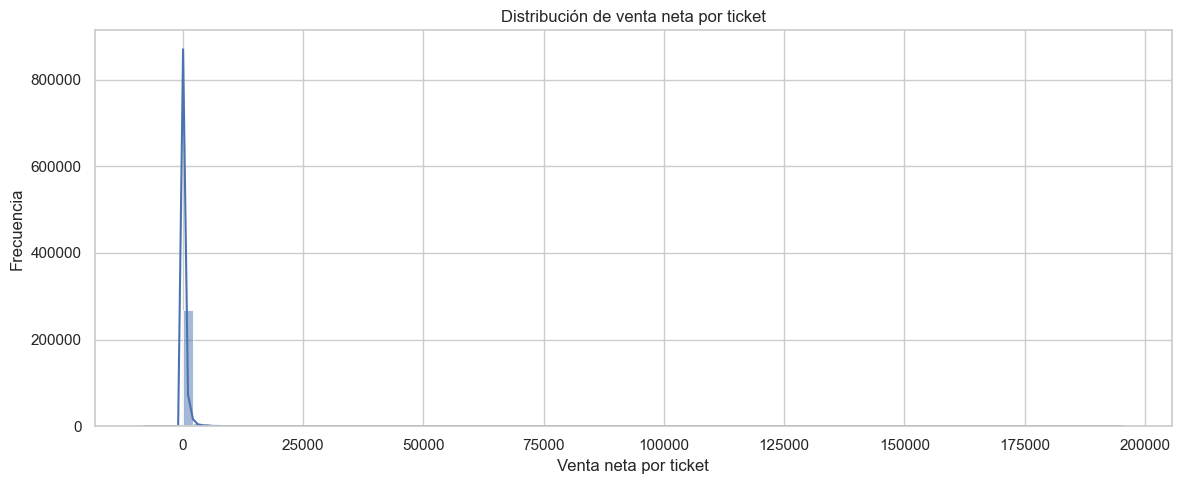

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\distribucion_venta_neta_ticket.png


In [9]:
# ===============================
# Distribución de venta neta por ticket
# ===============================

plt.figure(figsize=(12, 5))

sns.histplot(
    data=tickets,
    x="venta_neta",
    bins=100,
    kde=True
)

plt.title("Distribución de venta neta por ticket")
plt.xlabel("Venta neta por ticket")
plt.ylabel("Frecuencia")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "distribucion_venta_neta_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

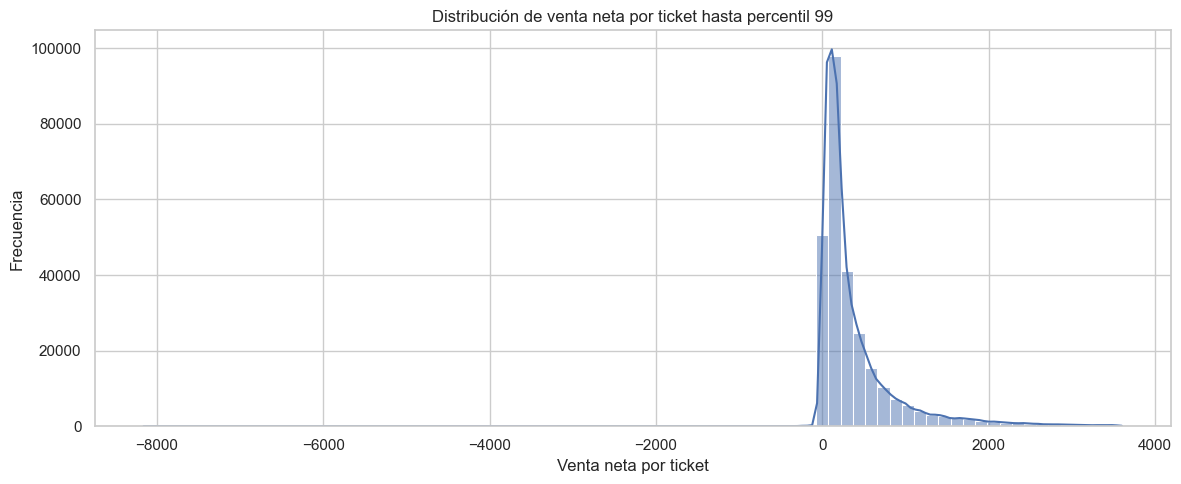

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\distribucion_venta_neta_ticket_p99.png


In [10]:
# ===============================
# Distribución de ticket sin extremos superiores
# ===============================

limite_99_ticket = tickets["venta_neta"].quantile(0.99)

tickets_sin_extremos = tickets[
    tickets["venta_neta"] <= limite_99_ticket
].copy()

plt.figure(figsize=(12, 5))

sns.histplot(
    data=tickets_sin_extremos,
    x="venta_neta",
    bins=80,
    kde=True
)

plt.title("Distribución de venta neta por ticket hasta percentil 99")
plt.xlabel("Venta neta por ticket")
plt.ylabel("Frecuencia")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "distribucion_venta_neta_ticket_p99.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

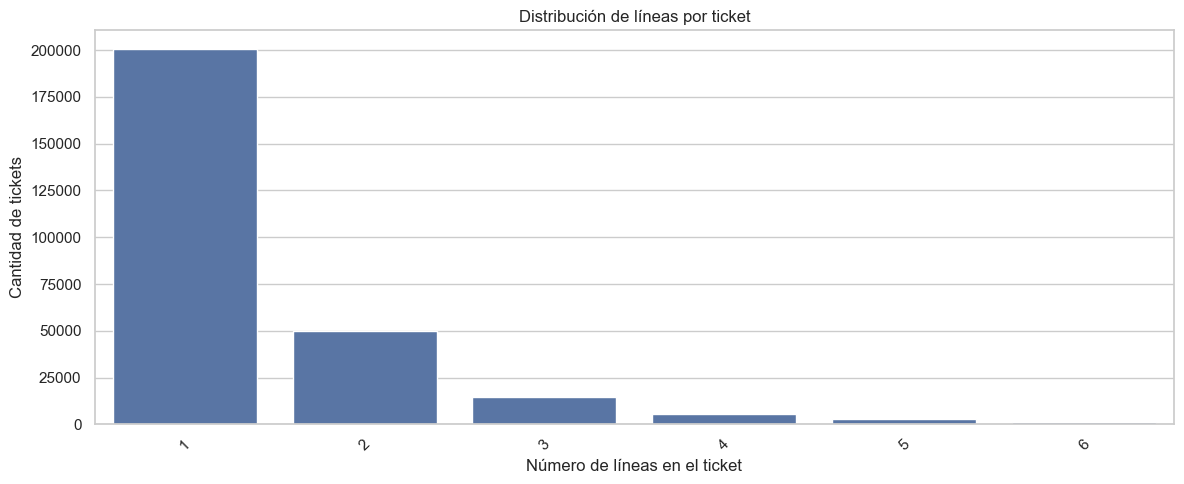

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\distribucion_lineas_por_ticket.png


In [11]:
# ===============================
# Distribución de líneas por ticket
# ===============================

plt.figure(figsize=(12, 5))

sns.countplot(
    data=tickets[tickets["lineas"] <= tickets["lineas"].quantile(0.99)],
    x="lineas"
)

plt.title("Distribución de líneas por ticket")
plt.xlabel("Número de líneas en el ticket")
plt.ylabel("Cantidad de tickets")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "distribucion_lineas_por_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

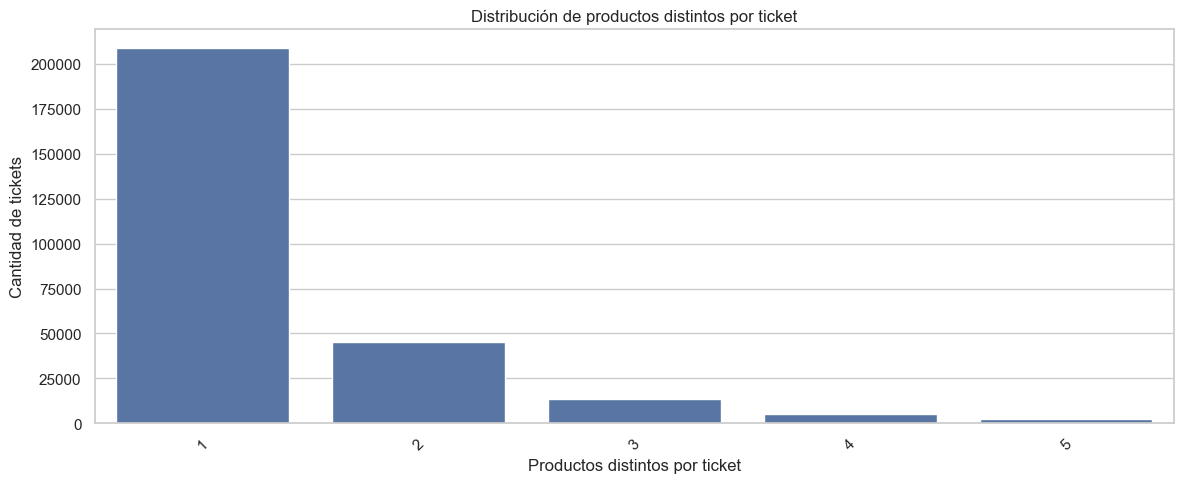

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\distribucion_productos_por_ticket.png


In [12]:
# ===============================
# Distribución de productos distintos por ticket
# ===============================

plt.figure(figsize=(12, 5))

sns.countplot(
    data=tickets[tickets["productos_distintos"] <= tickets["productos_distintos"].quantile(0.99)],
    x="productos_distintos"
)

plt.title("Distribución de productos distintos por ticket")
plt.xlabel("Productos distintos por ticket")
plt.ylabel("Cantidad de tickets")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "distribucion_productos_por_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [13]:
# ===============================
# Resumen de tickets por PDV
# ===============================

resumen_tickets_pdv = (
    tickets.groupby(["pdv", "estrato"])
    .agg(
        tickets=("TICKET_ID", "count"),
        venta_bruta=("venta_bruta", "sum"),
        descuento=("descuento", "sum"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas=("lineas", "sum"),
        productos_promedio=("productos_distintos", "mean"),
        categorias_promedio=("categorias_distintas", "mean"),
        lineas_promedio=("lineas", "mean"),
        ticket_promedio_neto=("venta_neta", "mean"),
        ticket_mediano_neto=("venta_neta", "median"),
        tickets_promo=("promo_flag_ticket", "sum"),
        tickets_especiales=("registro_especial_ticket", "sum")
    )
    .reset_index()
)

resumen_tickets_pdv["participacion_tickets_pct"] = (
    resumen_tickets_pdv["tickets"] / resumen_tickets_pdv["tickets"].sum() * 100
)

resumen_tickets_pdv["participacion_venta_neta_pct"] = (
    resumen_tickets_pdv["venta_neta"] / resumen_tickets_pdv["venta_neta"].sum() * 100
)

resumen_tickets_pdv["descuento_pct"] = np.where(
    resumen_tickets_pdv["venta_bruta"] > 0,
    resumen_tickets_pdv["descuento"] / resumen_tickets_pdv["venta_bruta"] * 100,
    np.nan
)

resumen_tickets_pdv["tickets_promo_pct"] = np.where(
    resumen_tickets_pdv["tickets"] > 0,
    resumen_tickets_pdv["tickets_promo"] / resumen_tickets_pdv["tickets"] * 100,
    np.nan
)

resumen_tickets_pdv["tickets_especiales_pct"] = np.where(
    resumen_tickets_pdv["tickets"] > 0,
    resumen_tickets_pdv["tickets_especiales"] / resumen_tickets_pdv["tickets"] * 100,
    np.nan
)

resumen_tickets_pdv = resumen_tickets_pdv.sort_values("venta_neta", ascending=False)

resumen_tickets_pdv

,pdv,estrato,tickets,venta_bruta,descuento,venta_neta,unidades,lineas,productos_promedio,categorias_promedio,lineas_promedio,ticket_promedio_neto,ticket_mediano_neto,tickets_promo,tickets_especiales,participacion_tickets_pct,participacion_venta_neta_pct,descuento_pct,tickets_promo_pct,tickets_especiales_pct
1,1311,6,129256,"80,638,414.00","8,777,219.00","71,861,195.00","232,738.60",201432,1.48,1.15,1.56,555.96,264.00,35639,5340,46.66,58.33,10.88,27.57,4.13
0,1255,4,93693,"38,023,322.00","5,281,154.00","32,742,168.00","165,580.55",132627,1.36,1.10,1.42,349.46,160.00,20810,3648,33.83,26.58,13.89,22.21,3.89
2,980,4,54040,"20,800,762.00","2,211,763.00","18,588,999.00","96,654.08",75701,1.32,1.08,1.40,343.99,180.00,13766,3021,19.51,15.09,10.63,25.47,5.59


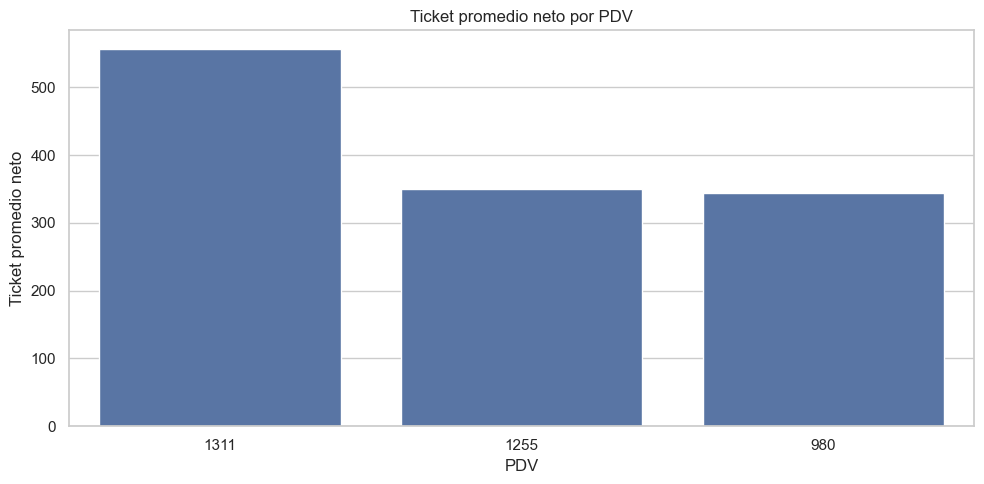

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\ticket_promedio_neto_pdv.png


In [14]:
# ===============================
# Ticket promedio neto por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_tickets_pdv,
    x="pdv",
    y="ticket_promedio_neto"
)

plt.title("Ticket promedio neto por PDV")
plt.xlabel("PDV")
plt.ylabel("Ticket promedio neto")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "ticket_promedio_neto_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

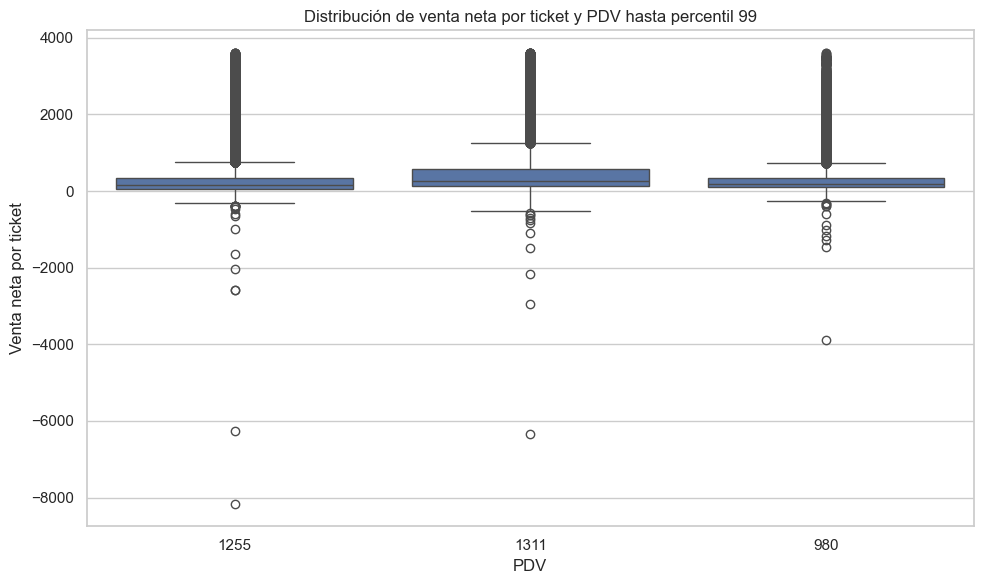

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\boxplot_ticket_neto_pdv_p99.png


In [15]:
# ===============================
# Distribución de ticket neto por PDV
# ===============================

tickets_boxplot = tickets[
    tickets["venta_neta"] <= tickets["venta_neta"].quantile(0.99)
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=tickets_boxplot,
    x="pdv",
    y="venta_neta"
)

plt.title("Distribución de venta neta por ticket y PDV hasta percentil 99")
plt.xlabel("PDV")
plt.ylabel("Venta neta por ticket")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "boxplot_ticket_neto_pdv_p99.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [16]:
# ===============================
# Resumen de tickets por año
# ===============================

resumen_tickets_anio = (
    tickets.groupby("anio")
    .agg(
        tickets=("TICKET_ID", "count"),
        venta_bruta=("venta_bruta", "sum"),
        descuento=("descuento", "sum"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas_promedio=("lineas", "mean"),
        productos_promedio=("productos_distintos", "mean"),
        ticket_promedio_neto=("venta_neta", "mean"),
        ticket_mediano_neto=("venta_neta", "median"),
        tickets_promo=("promo_flag_ticket", "sum")
    )
    .reset_index()
)

resumen_tickets_anio["descuento_pct"] = np.where(
    resumen_tickets_anio["venta_bruta"] > 0,
    resumen_tickets_anio["descuento"] / resumen_tickets_anio["venta_bruta"] * 100,
    np.nan
)

resumen_tickets_anio["tickets_promo_pct"] = np.where(
    resumen_tickets_anio["tickets"] > 0,
    resumen_tickets_anio["tickets_promo"] / resumen_tickets_anio["tickets"] * 100,
    np.nan
)

resumen_tickets_anio

,anio,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promedio,productos_promedio,ticket_promedio_neto,ticket_mediano_neto,tickets_promo,descuento_pct,tickets_promo_pct
0,2023,152896,"78,121,622.00","9,775,494.00","68,346,128.00","278,784.76",1.49,1.42,447.01,200.00,40826,12.51,26.70
1,2024,124093,"61,340,876.00","6,494,642.00","54,846,234.00","216,188.47",1.46,1.40,441.98,199.00,29389,10.59,23.68


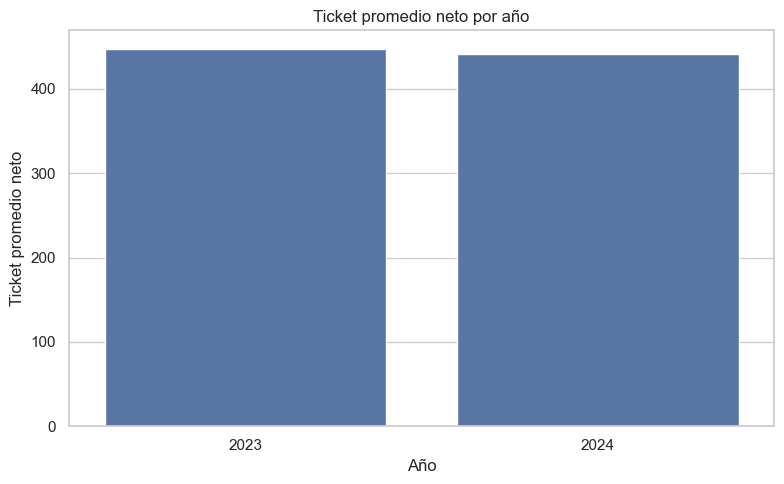

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\ticket_promedio_neto_anio.png


In [17]:
# ===============================
# Ticket promedio neto por año
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_tickets_anio,
    x="anio",
    y="ticket_promedio_neto"
)

plt.title("Ticket promedio neto por año")
plt.xlabel("Año")
plt.ylabel("Ticket promedio neto")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "ticket_promedio_neto_anio.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [18]:
# ===============================
# Resumen mensual de tickets
# ===============================

resumen_tickets_mensual = (
    tickets.groupby(["anio", "mes"])
    .agg(
        tickets=("TICKET_ID", "count"),
        venta_bruta=("venta_bruta", "sum"),
        descuento=("descuento", "sum"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas_promedio=("lineas", "mean"),
        productos_promedio=("productos_distintos", "mean"),
        ticket_promedio_neto=("venta_neta", "mean"),
        ticket_mediano_neto=("venta_neta", "median"),
        tickets_promo=("promo_flag_ticket", "sum")
    )
    .reset_index()
)

resumen_tickets_mensual["fecha_mes"] = pd.to_datetime(
    resumen_tickets_mensual["anio"].astype(str) + "-" +
    resumen_tickets_mensual["mes"].astype(str) + "-01"
)

resumen_tickets_mensual["tickets_promo_pct"] = np.where(
    resumen_tickets_mensual["tickets"] > 0,
    resumen_tickets_mensual["tickets_promo"] / resumen_tickets_mensual["tickets"] * 100,
    np.nan
)

resumen_tickets_mensual = resumen_tickets_mensual.sort_values("fecha_mes")

resumen_tickets_mensual.head()

,anio,mes,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promedio,productos_promedio,ticket_promedio_neto,ticket_mediano_neto,tickets_promo,fecha_mes,tickets_promo_pct
0,2023,1,12669,"6,211,723.00","745,966.00","5,465,757.00","22,597.54",1.52,1.43,431.43,199.00,3578,2023-01-01,28.24
1,2023,2,12400,"6,300,692.00","672,380.00","5,628,312.00","22,347.45",1.48,1.40,453.90,199.00,3588,2023-02-01,28.94
2,2023,3,12841,"6,691,739.00","859,475.00","5,832,264.00","22,791.83",1.52,1.44,454.19,200.00,3638,2023-03-01,28.33
3,2023,4,11494,"5,478,481.00","609,793.00","4,868,688.00","19,256.93",1.48,1.39,423.59,195.00,3130,2023-04-01,27.23
4,2023,5,12397,"6,399,346.00","814,573.00","5,584,773.00","22,820.27",1.47,1.41,450.49,190.00,3048,2023-05-01,24.59


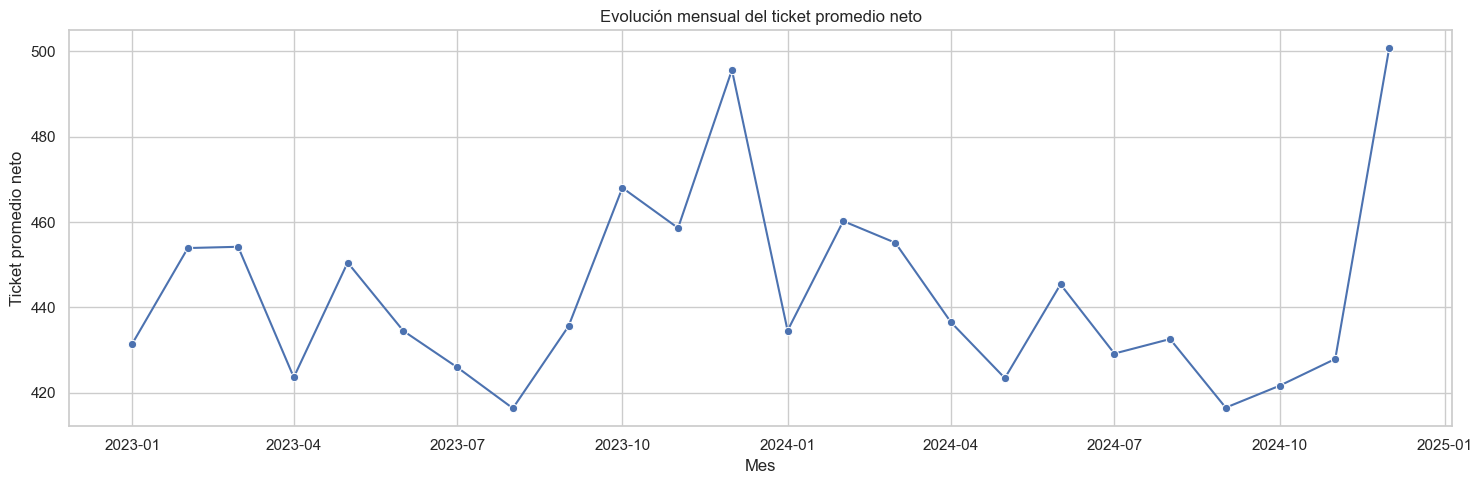

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\evolucion_mensual_ticket_promedio.png


In [19]:
# ===============================
# Evolución mensual del ticket promedio
# ===============================

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=resumen_tickets_mensual,
    x="fecha_mes",
    y="ticket_promedio_neto",
    marker="o"
)

plt.title("Evolución mensual del ticket promedio neto")
plt.xlabel("Mes")
plt.ylabel("Ticket promedio neto")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "evolucion_mensual_ticket_promedio.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [20]:
# ===============================
# Resumen por día de semana
# ===============================

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

resumen_tickets_dia_semana = (
    tickets.groupby(["dia_semana_num", "dia_semana_nombre"])
    .agg(
        tickets=("TICKET_ID", "count"),
        dias=("fecha", "nunique"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas_promedio=("lineas", "mean"),
        productos_promedio=("productos_distintos", "mean"),
        ticket_promedio_neto=("venta_neta", "mean"),
        ticket_mediano_neto=("venta_neta", "median"),
        tickets_promo=("promo_flag_ticket", "sum")
    )
    .reset_index()
    .sort_values("dia_semana_num")
)

resumen_tickets_dia_semana["tickets_promedio_dia"] = (
    resumen_tickets_dia_semana["tickets"] / resumen_tickets_dia_semana["dias"]
)

resumen_tickets_dia_semana["dia_semana_nombre"] = pd.Categorical(
    resumen_tickets_dia_semana["dia_semana_nombre"],
    categories=orden_dias,
    ordered=True
)

resumen_tickets_dia_semana

,dia_semana_num,dia_semana_nombre,tickets,dias,venta_neta,unidades,lineas_promedio,productos_promedio,ticket_promedio_neto,ticket_mediano_neto,tickets_promo,tickets_promedio_dia
0,0,Lunes,33825,105,"14,333,151.00","56,996.35",1.48,1.42,423.74,189.00,8212,322.14
1,1,Martes,37152,105,"16,333,083.00","63,219.81",1.47,1.41,439.63,194.00,7817,353.83
2,2,Miércoles,40346,104,"18,474,154.00","68,204.51",1.52,1.45,457.89,194.00,12339,387.94
3,3,Jueves,39150,104,"17,087,690.00","66,226.70",1.45,1.40,436.47,194.00,8501,376.44
4,4,Viernes,54430,104,"27,429,716.00","104,517.04",1.60,1.49,503.94,219.00,19279,523.37
5,5,Sábado,44608,104,"19,170,736.00","88,640.25",1.40,1.34,429.76,203.00,9401,428.92
6,6,Domingo,27478,105,"10,363,832.00","47,168.56",1.37,1.33,377.17,199.00,4666,261.70


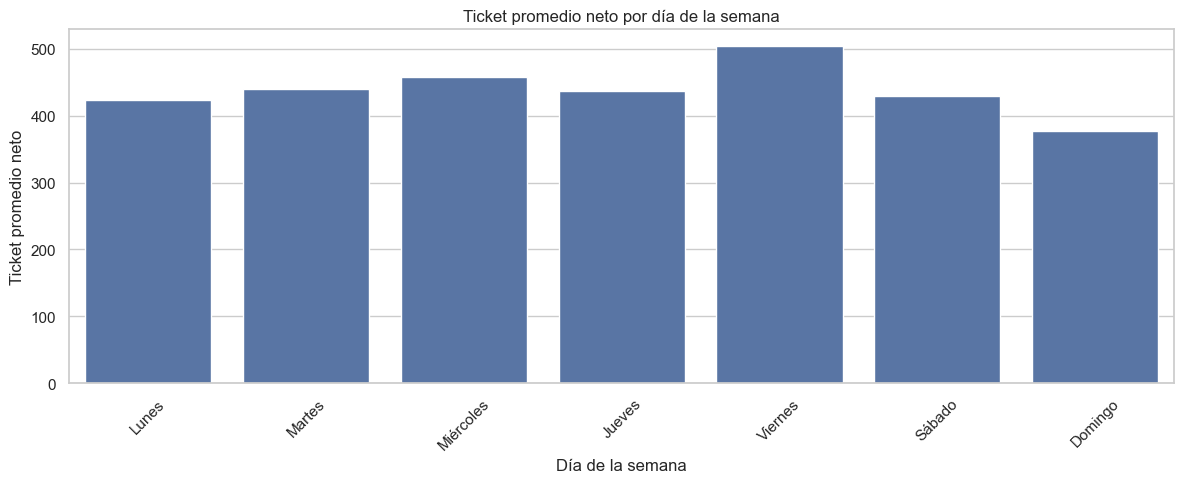

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\ticket_promedio_dia_semana.png


In [21]:
# ===============================
# Ticket promedio por día de semana
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_tickets_dia_semana,
    x="dia_semana_nombre",
    y="ticket_promedio_neto"
)

plt.title("Ticket promedio neto por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Ticket promedio neto")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "ticket_promedio_dia_semana.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

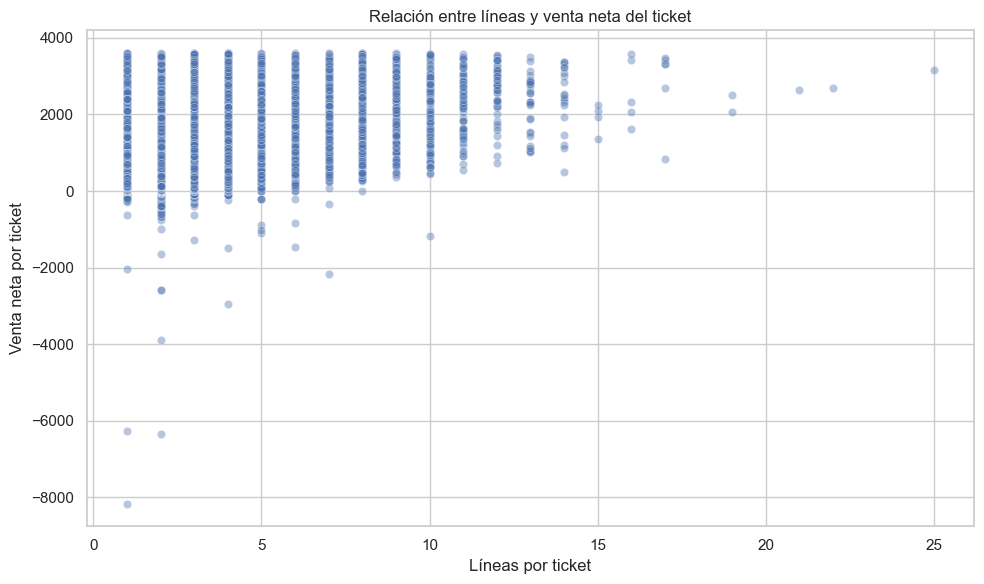

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\lineas_vs_venta_neta_ticket.png


In [22]:
# ===============================
# Relación líneas vs venta neta del ticket
# ===============================

tickets_scatter = tickets[
    tickets["venta_neta"] <= tickets["venta_neta"].quantile(0.99)
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tickets_scatter,
    x="lineas",
    y="venta_neta",
    alpha=0.4
)

plt.title("Relación entre líneas y venta neta del ticket")
plt.xlabel("Líneas por ticket")
plt.ylabel("Venta neta por ticket")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "lineas_vs_venta_neta_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

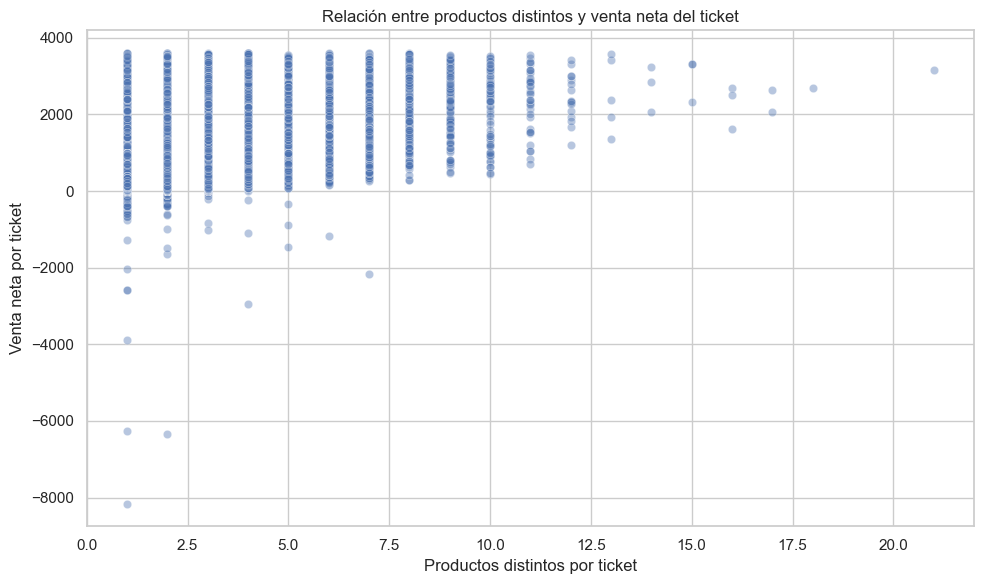

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\productos_vs_venta_neta_ticket.png


In [23]:
# ===============================
# Relación productos distintos vs venta neta del ticket
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tickets_scatter,
    x="productos_distintos",
    y="venta_neta",
    alpha=0.4
)

plt.title("Relación entre productos distintos y venta neta del ticket")
plt.xlabel("Productos distintos por ticket")
plt.ylabel("Venta neta por ticket")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "productos_vs_venta_neta_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [24]:
# ===============================
# Resumen tickets con promoción vs sin promoción
# ===============================

resumen_ticket_promo = (
    tickets.groupby("promo_flag_ticket")
    .agg(
        tickets=("TICKET_ID", "count"),
        venta_bruta=("venta_bruta", "sum"),
        descuento=("descuento", "sum"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas_promedio=("lineas", "mean"),
        productos_promedio=("productos_distintos", "mean"),
        ticket_promedio_neto=("venta_neta", "mean"),
        ticket_mediano_neto=("venta_neta", "median")
    )
    .reset_index()
)

resumen_ticket_promo["tipo_ticket"] = resumen_ticket_promo["promo_flag_ticket"].map({
    False: "Ticket sin promoción",
    True: "Ticket con promoción"
})

resumen_ticket_promo["participacion_tickets_pct"] = (
    resumen_ticket_promo["tickets"] / resumen_ticket_promo["tickets"].sum() * 100
)

resumen_ticket_promo["participacion_venta_neta_pct"] = (
    resumen_ticket_promo["venta_neta"] / resumen_ticket_promo["venta_neta"].sum() * 100
)

resumen_ticket_promo["descuento_pct"] = np.where(
    resumen_ticket_promo["venta_bruta"] > 0,
    resumen_ticket_promo["descuento"] / resumen_ticket_promo["venta_bruta"] * 100,
    np.nan
)

resumen_ticket_promo

,promo_flag_ticket,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promedio,productos_promedio,ticket_promedio_neto,ticket_mediano_neto,tipo_ticket,participacion_tickets_pct,participacion_venta_neta_pct,descuento_pct
0,False,206774,"79,384,923.00",0.00,"79,384,923.00","315,712.33",1.28,1.28,383.92,189.00,Ticket sin promoción,74.65,64.44,0.00
1,True,70215,"60,077,575.00","16,270,136.00","43,807,439.00","179,260.90",2.08,1.80,623.90,275.00,Ticket con promoción,25.35,35.56,27.08


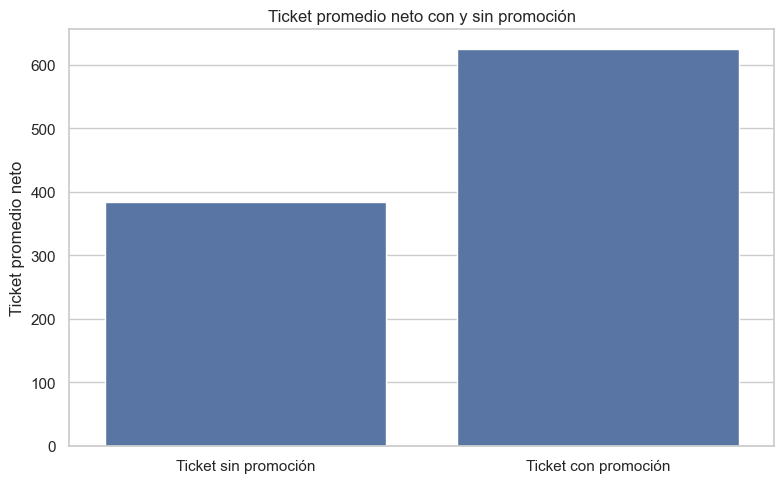

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\ticket_promedio_con_sin_promocion.png


In [25]:
# ===============================
# Ticket promedio con y sin promoción
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_ticket_promo,
    x="tipo_ticket",
    y="ticket_promedio_neto"
)

plt.title("Ticket promedio neto con y sin promoción")
plt.xlabel("")
plt.ylabel("Ticket promedio neto")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "ticket_promedio_con_sin_promocion.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [26]:
# ===============================
# Detección de tickets atípicos por IQR
# ===============================

q1 = tickets["venta_neta"].quantile(0.25)
q3 = tickets["venta_neta"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

tickets["FLAG_TICKET_ATIPICO_BAJO"] = tickets["venta_neta"] < limite_inferior
tickets["FLAG_TICKET_ATIPICO_ALTO"] = tickets["venta_neta"] > limite_superior
tickets["FLAG_TICKET_ATIPICO"] = (
    tickets["FLAG_TICKET_ATIPICO_BAJO"] |
    tickets["FLAG_TICKET_ATIPICO_ALTO"]
)

tickets_atipicos = tickets[tickets["FLAG_TICKET_ATIPICO"]].copy()

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Límite inferior: {limite_inferior:,.2f}")
print(f"Límite superior: {limite_superior:,.2f}")
print(f"Tickets atípicos detectados: {len(tickets_atipicos):,}")

tickets_atipicos.sort_values("venta_neta", ascending=False).head(30)

Q1: 95.00
Q3: 469.00
IQR: 374.00
Límite inferior: -466.00
Límite superior: 1,030.00
Tickets atípicos detectados: 26,474


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
183758,2024-03-20_1311_179637,2024-03-20,2024,3,2,Miércoles,1311,6,179637,1,1,1,"195,457.00",0.00,"195,457.00",45.00,0,0,1,0.00,False,0.00,45.00,"195,457.00",False,False,True,True
31684,2023-03-17_1311_19699,2023-03-17,2023,3,4,Viernes,1311,6,19699,1,1,1,"107,824.00","11,980.00","95,844.00",21.00,1,0,1,11.11,True,100.00,21.00,"95,844.00",False,False,True,True
176364,2024-02-29_1255_173042,2024-02-29,2024,2,3,Jueves,1255,4,173042,1,1,1,"95,200.00",0.00,"95,200.00",800.00,0,0,1,0.00,False,0.00,800.00,"95,200.00",False,False,True,True
275083,2024-12-28_1255_233169,2024-12-28,2024,12,5,Sábado,1255,4,233169,1,1,1,"78,000.00","26,000.00","52,000.00",400.00,1,0,1,33.33,True,100.00,400.00,"52,000.00",False,False,True,True
266414,2024-12-06_1255_205724,2024-12-06,2024,12,4,Viernes,1255,4,205724,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True
266400,2024-12-06_1255_202435,2024-12-06,2024,12,4,Viernes,1255,4,202435,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True
53989,2023-05-13_1255_53612,2023-05-13,2023,5,5,Sábado,1255,4,53612,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
53985,2023-05-13_1255_53605,2023-05-13,2023,5,5,Sábado,1255,4,53605,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
54067,2023-05-13_1255_53877,2023-05-13,2023,5,5,Sábado,1255,4,53877,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
53988,2023-05-13_1255_53611,2023-05-13,2023,5,5,Sábado,1255,4,53611,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True


In [27]:
# ===============================
# Top 30 tickets por venta neta
# ===============================

top_tickets_venta = (
    tickets
    .sort_values("venta_neta", ascending=False)
    .head(30)
    .copy()
)

top_tickets_venta

,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
183758,2024-03-20_1311_179637,2024-03-20,2024,3,2,Miércoles,1311,6,179637,1,1,1,"195,457.00",0.00,"195,457.00",45.00,0,0,1,0.00,False,0.00,45.00,"195,457.00",False,False,True,True
31684,2023-03-17_1311_19699,2023-03-17,2023,3,4,Viernes,1311,6,19699,1,1,1,"107,824.00","11,980.00","95,844.00",21.00,1,0,1,11.11,True,100.00,21.00,"95,844.00",False,False,True,True
176364,2024-02-29_1255_173042,2024-02-29,2024,2,3,Jueves,1255,4,173042,1,1,1,"95,200.00",0.00,"95,200.00",800.00,0,0,1,0.00,False,0.00,800.00,"95,200.00",False,False,True,True
275083,2024-12-28_1255_233169,2024-12-28,2024,12,5,Sábado,1255,4,233169,1,1,1,"78,000.00","26,000.00","52,000.00",400.00,1,0,1,33.33,True,100.00,400.00,"52,000.00",False,False,True,True
266414,2024-12-06_1255_205724,2024-12-06,2024,12,4,Viernes,1255,4,205724,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True
266400,2024-12-06_1255_202435,2024-12-06,2024,12,4,Viernes,1255,4,202435,2,1,1,"128,350.00","76,650.00","51,700.00","1,000.00",2,1,1,59.72,True,100.00,500.00,"25,850.00",True,False,True,True
53985,2023-05-13_1255_53605,2023-05-13,2023,5,5,Sábado,1255,4,53605,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
54067,2023-05-13_1255_53877,2023-05-13,2023,5,5,Sábado,1255,4,53877,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
53988,2023-05-13_1255_53611,2023-05-13,2023,5,5,Sábado,1255,4,53611,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True
53989,2023-05-13_1255_53612,2023-05-13,2023,5,5,Sábado,1255,4,53612,2,2,1,"50,065.00","8,835.00","41,230.00",200.00,2,0,2,17.65,True,100.00,100.00,"20,615.00",False,False,True,True


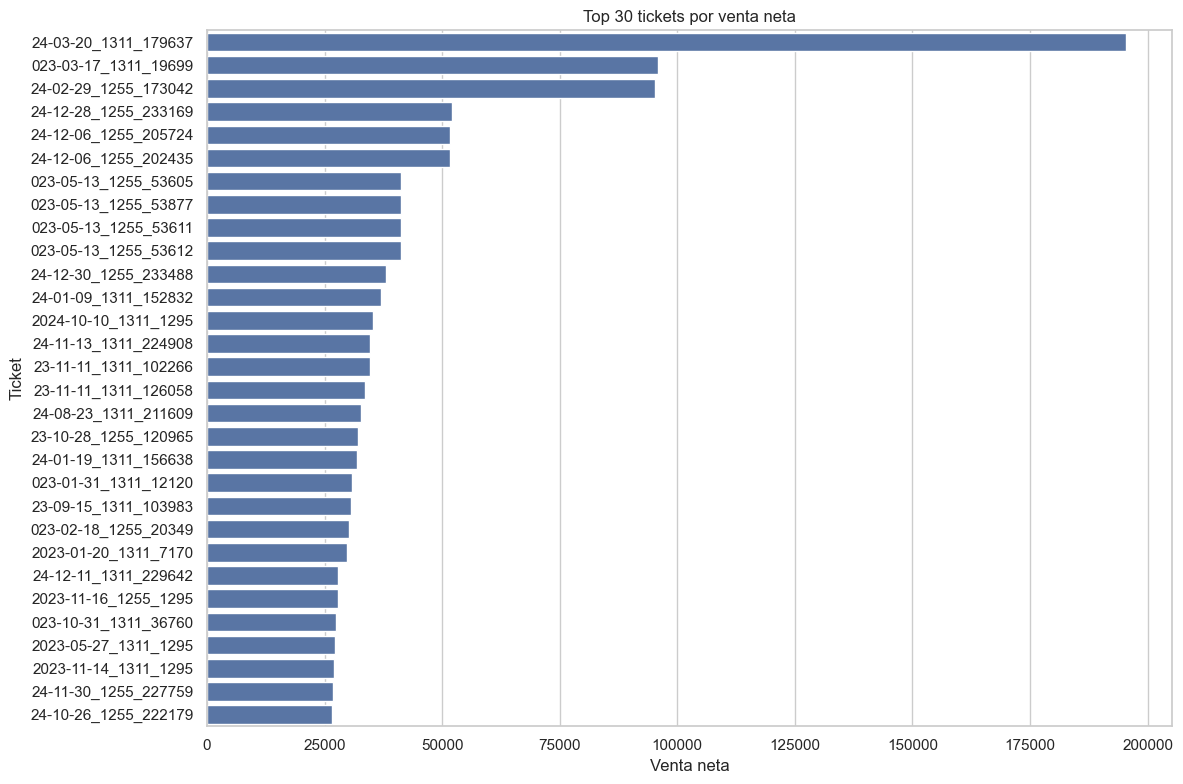

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\top_30_tickets_venta_neta.png


In [28]:
# ===============================
# Gráfico top tickets por venta neta
# ===============================

top_tickets_plot = top_tickets_venta.copy()
top_tickets_plot["ticket_corto"] = top_tickets_plot["TICKET_ID"].str[-20:]

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_tickets_plot,
    y="ticket_corto",
    x="venta_neta"
)

plt.title("Top 30 tickets por venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Ticket")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "top_30_tickets_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [29]:
# ===============================
# Tickets con venta neta negativa o cero
# ===============================

tickets_venta_negativa = tickets[tickets["venta_neta"] < 0].copy()
tickets_venta_cero = tickets[tickets["venta_neta"] == 0].copy()

print(f"Tickets con venta neta negativa: {len(tickets_venta_negativa):,}")
print(f"Tickets con venta neta cero: {len(tickets_venta_cero):,}")

tickets_venta_negativa.sort_values("venta_neta").head(30)

Tickets con venta neta negativa: 378
Tickets con venta neta cero: 2,391


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
163594,2024-01-30_1255_148354,2024-01-30,2024,1,1,Martes,1255,4,148354,1,1,1,"71,920.00","80,080.00","-8,160.00",800.00,1,1,0,111.35,True,100.00,800.00,"-8,160.00",True,True,False,True
3736,2023-01-11_1311_3599,2023-01-11,2023,1,2,Miércoles,1311,6,3599,2,2,1,"-7,690.00","-1,357.00","-6,333.00",-13.00,2,2,0,NaN,True,100.00,-6.50,"-3,166.50",True,True,False,True
163719,2024-01-30_1255_160808,2024-01-30,2024,1,1,Martes,1255,4,160808,1,1,1,"55,288.00","61,561.00","-6,273.00",615.00,1,1,0,111.35,True,100.00,615.00,"-6,273.00",True,True,False,True
250954,2024-10-13_980_216651,2024-10-13,2024,10,6,Domingo,980,4,216651,2,1,1,"15,960.00","19,840.00","-3,880.00",200.00,2,1,1,124.31,True,100.00,100.00,"-1,940.00",True,True,False,True
207113,2024-05-30_1311_1295,2024-05-30,2024,5,3,Jueves,1311,6,1295,4,4,3,"-2,946.00",0.00,"-2,946.00",-10.00,0,4,0,NaN,False,0.00,-2.50,-736.50,True,True,False,True
94027,2023-08-19_1255_93156,2023-08-19,2023,8,5,Sábado,1255,4,93156,2,1,1,"1,296.00","3,888.00","-2,592.00",48.00,2,1,1,300.00,True,100.00,24.00,"-1,296.00",True,True,False,True
94053,2023-08-19_1255_93275,2023-08-19,2023,8,5,Sábado,1255,4,93275,2,1,1,"1,296.00","3,888.00","-2,592.00",48.00,2,2,1,300.00,True,100.00,24.00,"-1,296.00",True,True,False,True
3685,2023-01-11_1311_3478,2023-01-11,2023,1,2,Miércoles,1311,6,3478,7,7,3,"-2,623.00",-466.00,"-2,157.00",-30.00,7,7,0,NaN,True,100.00,-4.29,-308.14,True,True,False,True
163746,2024-01-30_1255_160865,2024-01-30,2024,1,1,Martes,1255,4,160865,1,1,1,"17,980.00","20,020.00","-2,040.00",200.00,1,1,0,111.35,True,100.00,200.00,"-2,040.00",True,True,False,True
73320,2023-06-30_1255_73163,2023-06-30,2023,6,4,Viernes,1255,4,73163,2,2,1,192.00,"1,828.00","-1,636.00",2.00,2,1,1,952.08,True,100.00,1.00,-818.00,True,True,False,True


In [30]:
# ===============================
# Tickets con descuentos altos
# ===============================

tickets_descuento_alto = tickets[
    tickets["descuento_pct"] > tickets["descuento_pct"].quantile(0.99)
].copy()

print(f"Tickets con descuento por encima del percentil 99: {len(tickets_descuento_alto):,}")

tickets_descuento_alto.sort_values("descuento_pct", ascending=False).head(30)

Tickets con descuento por encima del percentil 99: 2,746


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
73320,2023-06-30_1255_73163,2023-06-30,2023,6,4,Viernes,1255,4,73163,2,2,1,192.00,"1,828.00","-1,636.00",2.00,2,1,1,952.08,True,100.00,1.00,-818.00,True,True,False,True
126853,2023-11-08_1311_125107,2023-11-08,2023,11,2,Miércoles,1311,6,125107,1,1,1,31.00,286.00,-255.00,1.00,1,1,0,922.58,True,100.00,1.00,-255.00,True,False,False,False
123049,2023-10-30_1311_121495,2023-10-30,2023,10,0,Lunes,1311,6,121495,1,1,1,31.00,286.00,-255.00,1.00,1,1,0,922.58,True,100.00,1.00,-255.00,True,False,False,False
123106,2023-10-30_1311_121552,2023-10-30,2023,10,0,Lunes,1311,6,121552,2,2,1,31.00,286.00,-255.00,1.00,1,2,0,922.58,True,50.00,0.50,-127.50,True,False,False,False
123091,2023-10-30_1311_121537,2023-10-30,2023,10,0,Lunes,1311,6,121537,1,1,1,31.00,286.00,-255.00,1.00,1,1,0,922.58,True,100.00,1.00,-255.00,True,False,False,False
129882,2023-11-16_1311_127917,2023-11-16,2023,11,3,Jueves,1311,6,127917,1,1,1,31.00,286.00,-255.00,1.00,1,1,0,922.58,True,100.00,1.00,-255.00,True,False,False,False
123082,2023-10-30_1311_121528,2023-10-30,2023,10,0,Lunes,1311,6,121528,2,1,1,63.00,572.00,-509.00,2.00,1,1,1,907.94,True,50.00,1.00,-254.50,True,True,False,True
123067,2023-10-30_1311_121513,2023-10-30,2023,10,0,Lunes,1311,6,121513,2,1,1,63.00,572.00,-509.00,2.00,1,1,1,907.94,True,50.00,1.00,-254.50,True,True,False,True
123066,2023-10-30_1311_121512,2023-10-30,2023,10,0,Lunes,1311,6,121512,2,1,1,63.00,572.00,-509.00,2.00,1,1,1,907.94,True,50.00,1.00,-254.50,True,True,False,True
123083,2023-10-30_1311_121529,2023-10-30,2023,10,0,Lunes,1311,6,121529,2,1,1,95.00,858.00,-763.00,3.00,1,1,1,903.16,True,50.00,1.50,-381.50,True,True,False,True


In [31]:
# ===============================
# Tickets con muchas líneas
# ===============================

tickets_muchas_lineas = tickets[
    tickets["lineas"] > tickets["lineas"].quantile(0.99)
].copy()

print(f"Tickets con líneas por encima del percentil 99: {len(tickets_muchas_lineas):,}")

tickets_muchas_lineas.sort_values("lineas", ascending=False).head(30)

Tickets con líneas por encima del percentil 99: 2,272


,TICKET_ID,fecha,anio,mes,dia_semana_num,dia_semana_nombre,pdv,estrato,factura,lineas,productos_distintos,categorias_distintas,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,descuento_pct,promo_flag_ticket,promo_pct_lineas,unidades_por_linea,venta_neta_por_linea,registro_especial_ticket,FLAG_TICKET_ATIPICO_BAJO,FLAG_TICKET_ATIPICO_ALTO,FLAG_TICKET_ATIPICO
30984,2023-03-15_980_18819,2023-03-15,2023,3,2,Miércoles,980,4,18819,53,33,2,"9,507.00","1,724.00","7,783.00",62.13,33,4,49,18.13,True,62.26,1.17,146.85,True,False,True,True
86458,2023-07-31_980_60278,2023-07-31,2023,7,0,Lunes,980,4,60278,50,43,3,"11,143.00","2,924.00","8,219.00",57.92,43,3,47,26.24,True,86.00,1.16,164.38,True,False,True,True
6015,2023-01-16_980_5530,2023-01-16,2023,1,0,Lunes,980,4,5530,46,34,2,"8,104.00","1,415.00","6,689.00",56.00,34,2,44,17.46,True,73.91,1.22,145.41,True,False,True,True
60753,2023-05-31_1255_60316,2023-05-31,2023,5,2,Miércoles,1255,4,60316,45,32,4,"17,632.00","5,464.00","12,168.00",48.64,32,6,39,30.99,True,71.11,1.08,270.40,True,False,True,True
207435,2024-05-31_1255_162853,2024-05-31,2024,5,4,Viernes,1255,4,162853,42,33,4,"19,529.00","5,268.00","14,261.00",45.00,31,1,41,26.98,True,73.81,1.07,339.55,True,False,True,True
236824,2024-08-30_1255_194093,2024-08-30,2024,8,4,Viernes,1255,4,194093,38,27,4,"14,756.00","3,693.00","11,063.00",46.00,25,4,34,25.03,True,65.79,1.21,291.13,True,False,True,True
135466,2023-11-30_1255_72396,2023-11-30,2023,11,3,Jueves,1255,4,72396,38,32,4,"20,072.00","5,008.00","15,064.00",51.25,32,1,37,24.95,True,84.21,1.35,396.42,True,False,True,True
30986,2023-03-15_980_18968,2023-03-15,2023,3,2,Miércoles,980,4,18968,37,30,3,"5,992.00","1,138.00","4,854.00",44.00,30,2,35,18.99,True,81.08,1.19,131.19,True,False,True,True
18954,2023-02-15_980_18417,2023-02-15,2023,2,2,Miércoles,980,4,18417,37,32,3,"6,732.00","1,228.00","5,504.00",40.00,32,0,37,18.24,True,86.49,1.08,148.76,False,False,True,True
183709,2024-03-20_1311_179569,2024-03-20,2024,3,2,Miércoles,1311,6,179569,36,31,3,"21,610.00",983.00,"20,627.00",44.00,24,0,36,4.55,True,66.67,1.22,572.97,False,False,True,True


In [32]:
# ===============================
# Detalle de líneas de los tickets top
# ===============================

ids_top_tickets = top_tickets_venta["TICKET_ID"].tolist()

detalle_top_tickets = df[
    df["TICKET_ID"].isin(ids_top_tickets)
].copy()

detalle_top_tickets = detalle_top_tickets.sort_values(
    ["TICKET_ID", "VENTA_NETA"],
    ascending=[True, False]
)

detalle_top_tickets[[
    "TICKET_ID",
    "FECHA",
    "PDV",
    "FACTURA",
    "CATEG",
    "PLU_SAP",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "PROMO_FLAG"
]].head(50)

,TICKET_ID,FECHA,PDV,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,PROMO_FLAG
10816,2023-01-20_1311_7170,2023-01-20,1311,7170,08042,1147999,9.00,"22,590.00","3,986.00","18,604.00",True
10453,2023-01-20_1311_7170,2023-01-20,1311,7170,08042,1236508,5.00,"7,118.00","1,256.00","5,862.00",True
10291,2023-01-20_1311_7170,2023-01-20,1311,7170,08042,1010812,5.00,"6,434.00","1,135.00","5,299.00",True
18005,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1143369,35.00,"18,424.00","4,606.00","13,818.00",True
18780,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1147999,5.00,"11,812.00","2,953.00","8,859.00",True
17342,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1016872,10.00,"5,520.00","1,380.00","4,140.00",True
17531,2023-01-31_1311_12120,2023-01-31,1311,12120,08042,1172514,4.00,"2,355.00",588.00,"1,767.00",True
17578,2023-01-31_1311_12120,2023-01-31,1311,12120,08062,1019083,7.00,"3,431.00","2,287.00","1,144.00",True
18831,2023-01-31_1311_12120,2023-01-31,1311,12120,08029,1246898,5.00,"1,376.00",344.00,"1,032.00",True
30164,2023-02-18_1255_20349,2023-02-18,1255,20349,04010,1041245,96.00,"28,796.00","5,082.00","23,714.00",True


In [33]:
# ===============================
# Categorías en tickets
# ===============================

categorias_ticket = (
    df.groupby(["TICKET_ID", "CATEG"])
    .agg(
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas=("NroReg", "count")
    )
    .reset_index()
)

resumen_categorias_ticket = (
    categorias_ticket.groupby("CATEG")
    .agg(
        tickets=("TICKET_ID", "nunique"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        lineas=("lineas", "sum")
    )
    .reset_index()
    .sort_values("tickets", ascending=False)
)

resumen_categorias_ticket["participacion_tickets_pct"] = (
    resumen_categorias_ticket["tickets"] / tickets["TICKET_ID"].nunique() * 100
)

resumen_categorias_ticket

,CATEG,tickets,venta_neta,unidades,lineas,participacion_tickets_pct
0,04010,121604,"53,779,358.00","244,163.00",158659,43.90
2,08029,95594,"25,966,820.00","123,061.92",132505,34.51
4,08061,42098,"10,153,870.00","54,349.08",53538,15.20
3,08042,41127,"27,116,982.00","60,593.26",52788,14.85
5,08062,8608,"5,445,517.00","10,972.18",10997,3.11
1,04019,392,"31,602.00",460.00,397,0.14
6,08067,355,"698,213.00","1,373.79",876,0.13


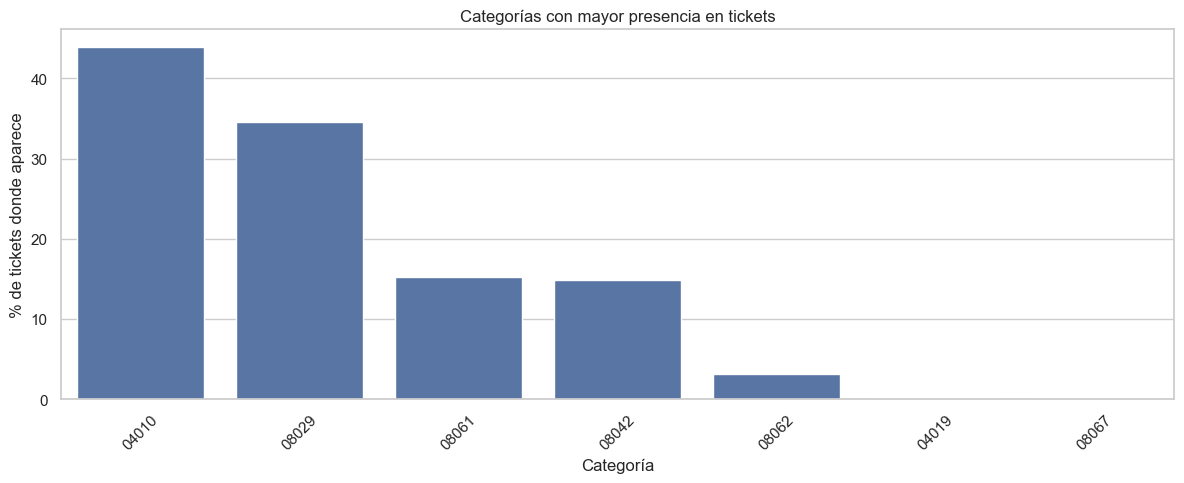

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\categorias_presencia_tickets.png


In [34]:
# ===============================
# Categorías con mayor presencia en tickets
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_categorias_ticket.head(15),
    x="CATEG",
    y="participacion_tickets_pct"
)

plt.title("Categorías con mayor presencia en tickets")
plt.xlabel("Categoría")
plt.ylabel("% de tickets donde aparece")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "categorias_presencia_tickets.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [35]:
# ===============================
# Productos más presentes en tickets
# ===============================

productos_ticket = (
    df.groupby("PLU_SAP")
    .agg(
        tickets=("TICKET_ID", "nunique"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas=("NroReg", "count"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
)

productos_ticket["participacion_tickets_pct"] = (
    productos_ticket["tickets"] / tickets["TICKET_ID"].nunique() * 100
)

productos_ticket = productos_ticket.sort_values("tickets", ascending=False)

productos_ticket.head(30)

,PLU_SAP,tickets,venta_neta,unidades,lineas,categoria_principal,participacion_tickets_pct
4936,1338873,8064,"1,311,741.00","13,508.00",8419,04010,2.91
1513,1036246,7675,"1,958,957.00","10,799.00",7872,04010,2.77
1515,1036252,4735,"1,225,589.00","8,419.00",5075,04010,1.71
1518,1036266,4397,"1,627,878.00","14,374.00",4699,04010,1.59
4155,1313279,4299,"1,082,770.00","6,971.00",4665,04010,1.55
1179,1019569,2835,"111,435.00","3,300.00",2950,08061,1.02
1516,1036253,2682,"1,208,016.00","14,342.00",2824,04010,0.97
3674,1281570,2529,"280,278.00","3,721.00",2719,08029,0.91
3994,1299851,2430,"270,646.00","3,507.00",2593,08029,0.88
3580,1273557,2266,"473,627.00","3,402.00",2415,04010,0.82


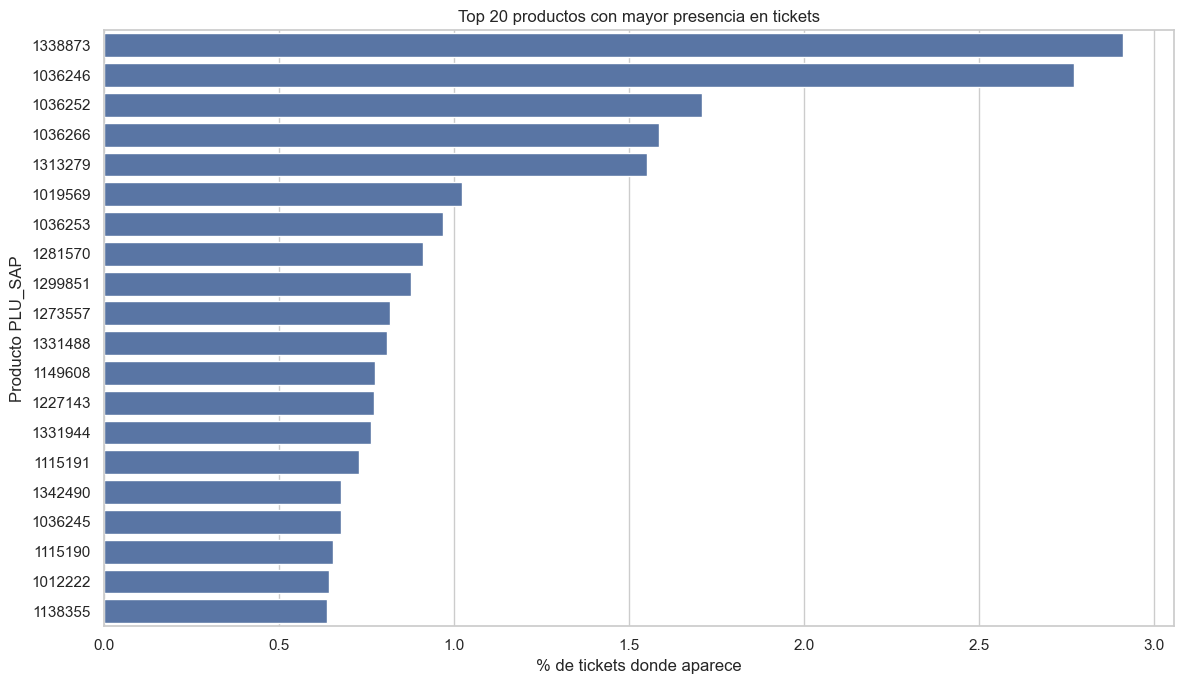

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\top_productos_presencia_tickets.png


In [36]:
# ===============================
# Top productos por presencia en tickets
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=productos_ticket.head(20),
    y="PLU_SAP",
    x="participacion_tickets_pct"
)

plt.title("Top 20 productos con mayor presencia en tickets")
plt.xlabel("% de tickets donde aparece")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "top_productos_presencia_tickets.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

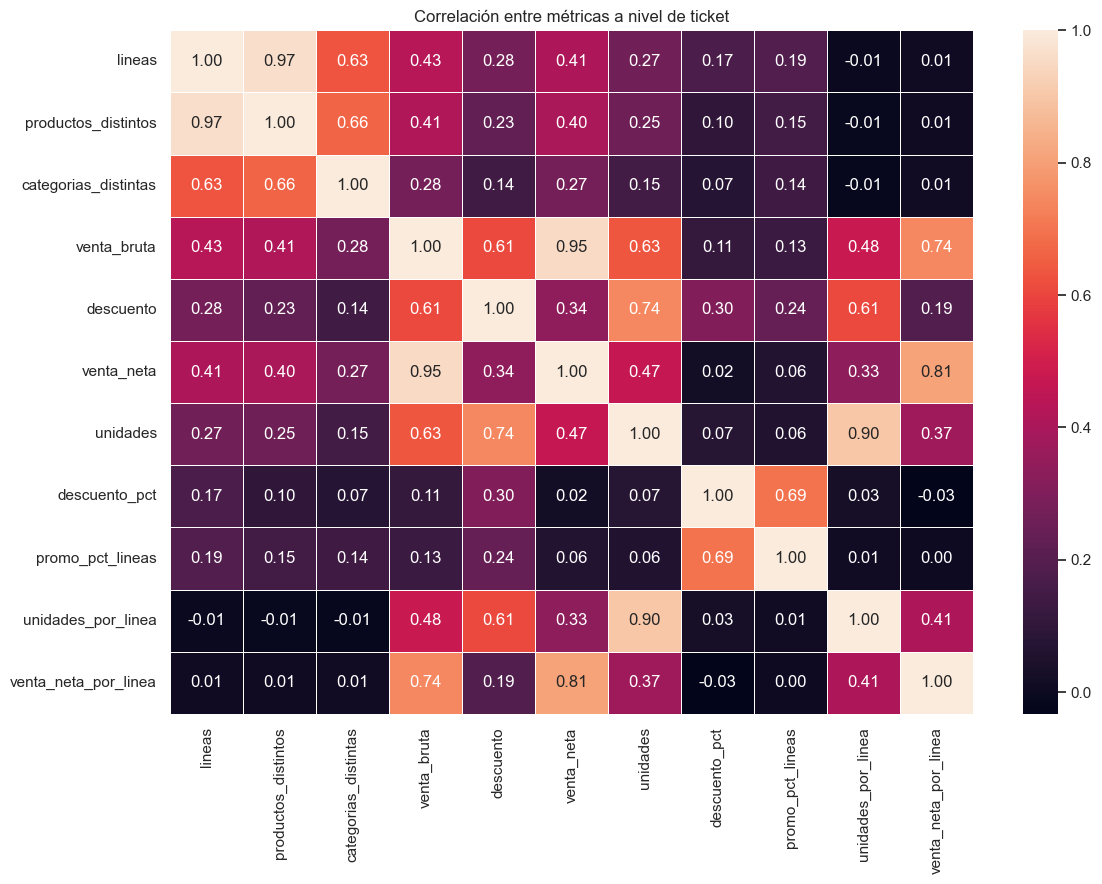

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\tickets\correlacion_metricas_ticket.png


In [37]:
# ===============================
# Correlación de métricas por ticket
# ===============================

cols_corr_ticket = [
    "lineas",
    "productos_distintos",
    "categorias_distintas",
    "venta_bruta",
    "descuento",
    "venta_neta",
    "unidades",
    "descuento_pct",
    "promo_pct_lineas",
    "unidades_por_linea",
    "venta_neta_por_linea"
]

corr_ticket = tickets[cols_corr_ticket].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_ticket,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación entre métricas a nivel de ticket")
plt.tight_layout()

output_fig = TICKETS_FIGURES_DIR / "correlacion_metricas_ticket.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [38]:
# ===============================
# Resumen ejecutivo de tickets
# ===============================

resumen_ejecutivo_tickets = pd.DataFrame({
    "metrica": [
        "Tickets únicos",
        "Ticket promedio neto",
        "Ticket mediano neto",
        "Máximo ticket neto",
        "Mínimo ticket neto",
        "Promedio líneas por ticket",
        "Promedio productos por ticket",
        "Promedio categorías por ticket",
        "PDV con mayor ticket promedio",
        "Mayor ticket promedio por PDV",
        "Día de semana con mayor ticket promedio",
        "Mayor ticket promedio por día de semana",
        "Tickets con promoción",
        "% tickets con promoción",
        "Tickets atípicos",
        "Tickets con venta neta negativa",
        "Tickets con venta neta cero"
    ],
    "valor": [
        tickets["TICKET_ID"].nunique(),
        tickets["venta_neta"].mean(),
        tickets["venta_neta"].median(),
        tickets["venta_neta"].max(),
        tickets["venta_neta"].min(),
        tickets["lineas"].mean(),
        tickets["productos_distintos"].mean(),
        tickets["categorias_distintas"].mean(),
        resumen_tickets_pdv.sort_values("ticket_promedio_neto", ascending=False).iloc[0]["pdv"],
        resumen_tickets_pdv.sort_values("ticket_promedio_neto", ascending=False).iloc[0]["ticket_promedio_neto"],
        resumen_tickets_dia_semana.sort_values("ticket_promedio_neto", ascending=False).iloc[0]["dia_semana_nombre"],
        resumen_tickets_dia_semana.sort_values("ticket_promedio_neto", ascending=False).iloc[0]["ticket_promedio_neto"],
        tickets["promo_flag_ticket"].sum(),
        tickets["promo_flag_ticket"].mean() * 100,
        tickets["FLAG_TICKET_ATIPICO"].sum(),
        (tickets["venta_neta"] < 0).sum(),
        (tickets["venta_neta"] == 0).sum()
    ]
})

resumen_ejecutivo_tickets

,metrica,valor
0,Tickets únicos,276989
1,Ticket promedio neto,444.76
2,Ticket mediano neto,199.00
3,Máximo ticket neto,"195,457.00"
4,Mínimo ticket neto,"-8,160.00"
5,Promedio líneas por ticket,1.48
6,Promedio productos por ticket,1.41
7,Promedio categorías por ticket,1.12
8,PDV con mayor ticket promedio,1311
9,Mayor ticket promedio por PDV,555.96


In [39]:
# ===============================
# Exportar tablas del análisis de tickets
# ===============================

output_excel = TABLES_DIR / "07_analisis_tickets_facturas.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_general_tickets.to_excel(writer, sheet_name="resumen_general", index=False)
    estadisticos_tickets.to_excel(writer, sheet_name="estadisticos_tickets", index=True)
    tickets.to_excel(writer, sheet_name="tickets", index=False)
    resumen_tickets_pdv.to_excel(writer, sheet_name="tickets_pdv", index=False)
    resumen_tickets_anio.to_excel(writer, sheet_name="tickets_anio", index=False)
    resumen_tickets_mensual.to_excel(writer, sheet_name="tickets_mensual", index=False)
    resumen_tickets_dia_semana.to_excel(writer, sheet_name="tickets_dia_semana", index=False)
    resumen_ticket_promo.to_excel(writer, sheet_name="tickets_promo", index=False)
    tickets_atipicos.to_excel(writer, sheet_name="tickets_atipicos", index=False)
    top_tickets_venta.to_excel(writer, sheet_name="top_tickets_venta", index=False)
    tickets_venta_negativa.to_excel(writer, sheet_name="tickets_venta_negativa", index=False)
    tickets_venta_cero.to_excel(writer, sheet_name="tickets_venta_cero", index=False)
    tickets_descuento_alto.to_excel(writer, sheet_name="tickets_descuento_alto", index=False)
    tickets_muchas_lineas.to_excel(writer, sheet_name="tickets_muchas_lineas", index=False)
    detalle_top_tickets.to_excel(writer, sheet_name="detalle_top_tickets", index=False)
    resumen_categorias_ticket.to_excel(writer, sheet_name="categorias_ticket", index=False)
    productos_ticket.to_excel(writer, sheet_name="productos_ticket", index=False)
    corr_ticket.to_excel(writer, sheet_name="corr_ticket", index=True)
    resumen_ejecutivo_tickets.to_excel(writer, sheet_name="resumen_ejecutivo", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\07_analisis_tickets_facturas.xlsx


In [40]:
# ===============================
# Guardar base de tickets
# ===============================

TICKETS_FILE = PROCESSED_DIR / "tickets_eda.parquet"

tickets.to_parquet(TICKETS_FILE, index=False)

print("Base de tickets guardada correctamente.")
print(f"Ruta: {TICKETS_FILE}")
print(f"Filas: {tickets.shape[0]:,}")
print(f"Columnas: {tickets.shape[1]:,}")

Base de tickets guardada correctamente.
Ruta: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\tickets_eda.parquet
Filas: 276,989
Columnas: 28


## Conclusiones del análisis de tickets y facturas

A partir del análisis a nivel de ticket, se identifican varios elementos relevantes:

1. La base original está a nivel de línea de venta, por lo que fue necesario construir una base agregada a nivel de ticket utilizando `TICKET_ID`.

2. El análisis de ticket promedio permite entender el valor medio de compra por transacción, más allá del volumen total vendido.

3. La cantidad de líneas, productos y categorías por ticket permite analizar la composición de las compras.

4. La comparación por PDV muestra si las tiendas tienen diferencias en el valor promedio del ticket, cantidad de productos por compra o presencia de promociones.

5. El análisis mensual permite observar si el valor del ticket cambia a lo largo del tiempo.

6. El análisis por día de la semana permite identificar si los clientes compran tickets de mayor o menor valor dependiendo del día.

7. Los tickets con promoción deben analizarse por separado porque pueden tener diferencias importantes en venta neta, descuento, unidades y número de productos.

8. Los tickets atípicos no deben eliminarse automáticamente. Pueden representar compras grandes, ajustes, devoluciones, errores de registro o comportamientos comerciales especiales.

9. Los tickets con venta neta negativa o cero requieren revisión porque pueden estar asociados a devoluciones, descuentos mayores que la venta, notas crédito o ajustes operativos.

10. Para un futuro modelo de predicción, las variables agregadas por ticket pueden servir para crear indicadores como ticket promedio diario, productos promedio por ticket, líneas promedio por ticket y porcentaje de tickets promocionales.